In [3]:
from skimage import io, color
from skimage.morphology import binary_closing, binary_opening
from skimage.morphology import disk
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
from skimage.color import label2rgb
import pydicom as dicom
from scipy.stats import norm
from scipy.spatial import distance
import math
from skimage.transform import rotate
from skimage.transform import EuclideanTransform
from skimage.transform import SimilarityTransform
from skimage.transform import warp
from skimage.transform import swirl

In [4]:
def show_comparison(original, transformed, transformed_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(transformed)
    ax2.set_title(transformed_name)
    ax2.axis('off')
    io.show()

Exercise 1

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


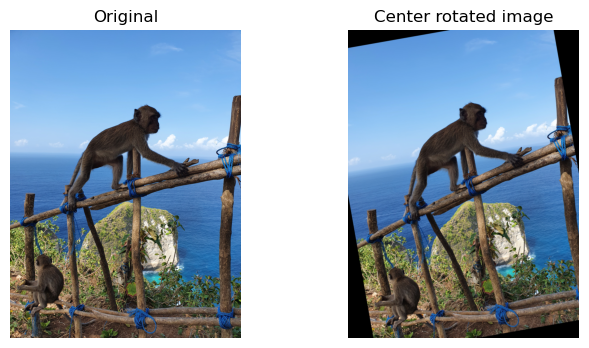

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


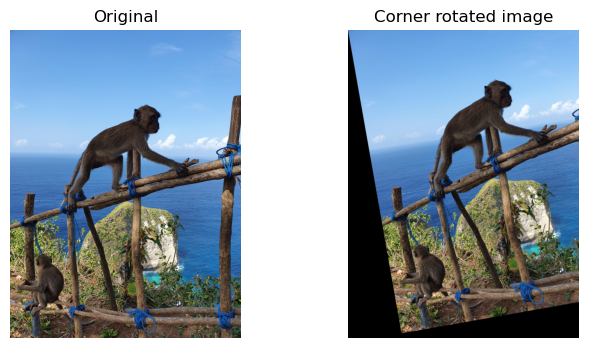

In [5]:
img_name = "NusaPenida.png"
img_path = "data/"

im_org = io.imread(img_path + img_name)

# angle in degrees - counter clockwise
rotation_angle = 10
rotated_img1 = rotate(im_org, rotation_angle)

rot_center = [0, 0]
rotated_img2 = rotate(im_org, rotation_angle, center=rot_center)

show_comparison(im_org, rotated_img1, "Center rotated image")
show_comparison(im_org, rotated_img2, "Corner rotated image")

Exercise 2

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


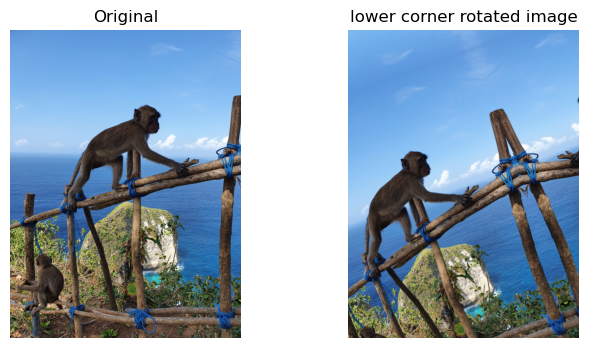

In [7]:
rot_center = [im_org.shape[1], im_org.shape[0]]
rotated_img3 = rotate(im_org, rotation_angle+10, mode="reflect", center = rot_center)
show_comparison(im_org, rotated_img3, "lower corner rotated image")

Exercise 3

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


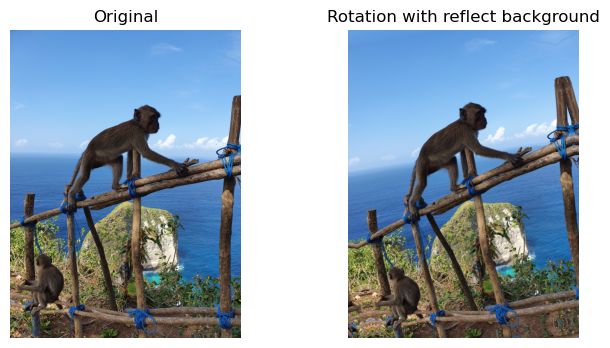

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


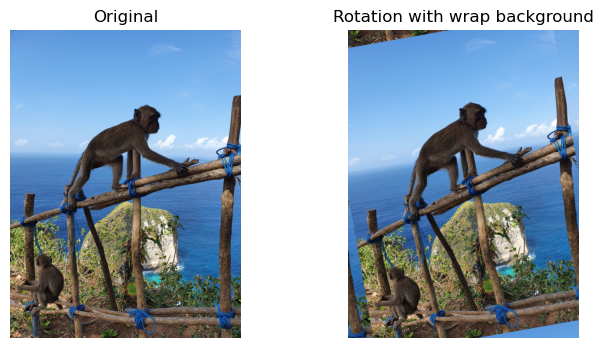

In [8]:
rotated_reflect = rotate(im_org, rotation_angle, mode="reflect")
rotated_wrap = rotate(im_org, rotation_angle, mode="wrap")

show_comparison(im_org, rotated_reflect, "Rotation with reflect background")
show_comparison(im_org, rotated_wrap, "Rotation with wrap background")

Exercise 4

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


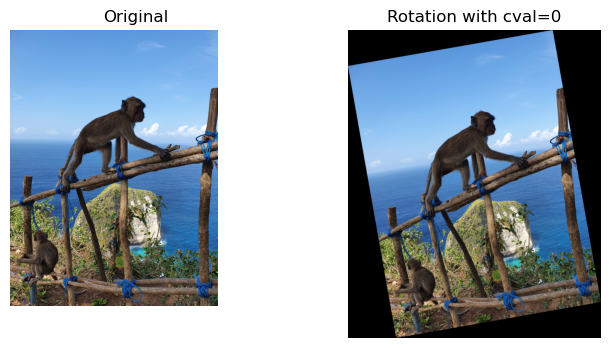

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


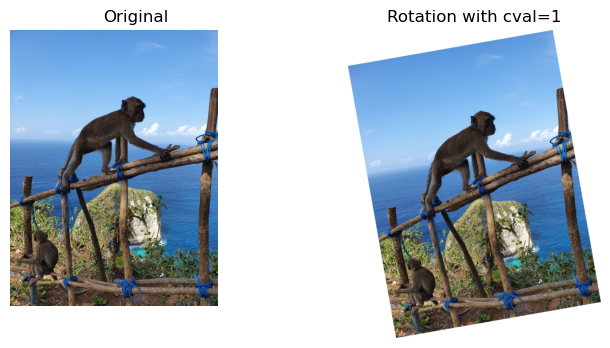

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [7.438175747650486e-05..255.0].
C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


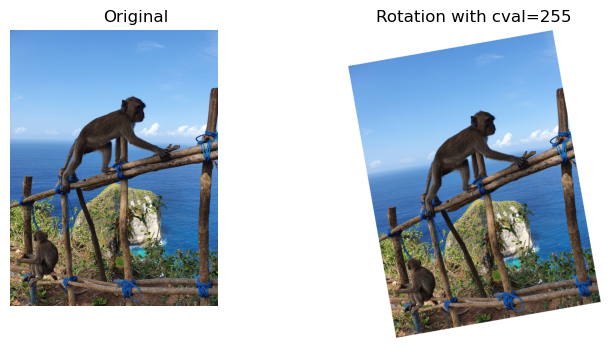

In [9]:
rotated_const1 = rotate(im_org, rotation_angle, resize=True, mode="constant", cval=0)
rotated_const2 = rotate(im_org, rotation_angle, resize=True, mode="constant", cval=1)
rotated_const3 = rotate(im_org, rotation_angle, resize=True, mode="constant", cval=255)

show_comparison(im_org, rotated_const1, "Rotation with cval=0")
show_comparison(im_org, rotated_const2, "Rotation with cval=1")
show_comparison(im_org, rotated_const3, "Rotation with cval=255")

Exercise 5

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


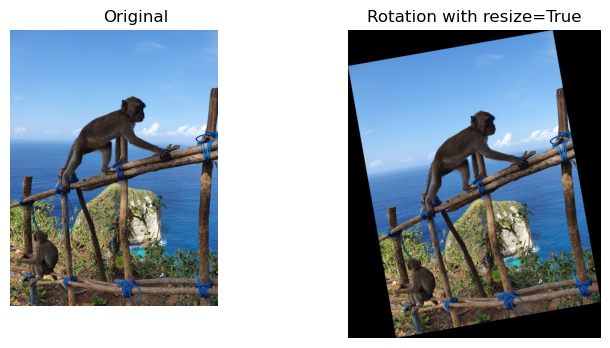

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


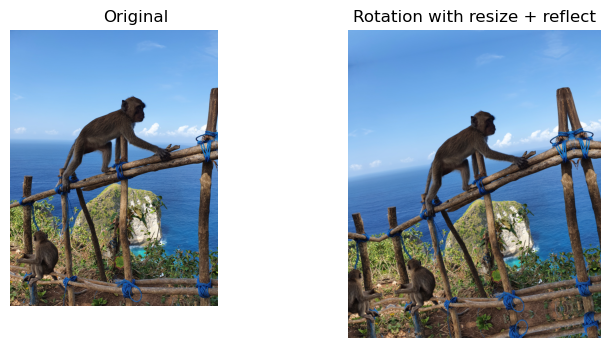

In [10]:
rotated_resize = rotate(im_org, rotation_angle, resize=True)
rotated_resize_reflect = rotate(im_org, rotation_angle, resize=True, mode="reflect")

show_comparison(im_org, rotated_resize, "Rotation with resize=True")
show_comparison(im_org, rotated_resize_reflect, "Rotation with resize + reflect")

Exercise 6

In [11]:
import math
from skimage.transform import EuclideanTransform, warp

rotation_angle_rad = 10.0 * math.pi / 180.0
trans = [10, 20]
tform = EuclideanTransform(rotation=rotation_angle_rad, translation=trans)
print("Transformation matrix:\n", tform.params)

Transformation matrix:
 [[ 0.98480775 -0.17364818 10.        ]
 [ 0.17364818  0.98480775 20.        ]
 [ 0.          0.          1.        ]]


Exercise 7

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


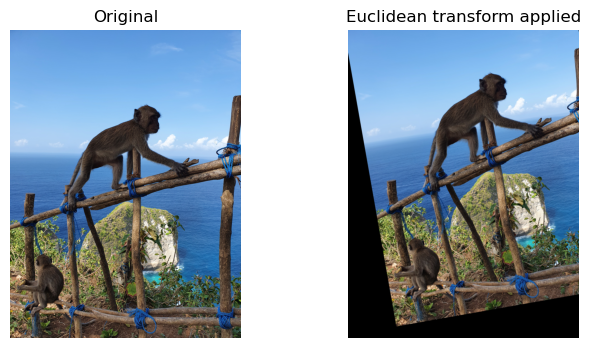

In [12]:
transformed_img = warp(im_org, tform)
show_comparison(im_org, transformed_img, "Euclidean transform applied")

Exercise 8

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


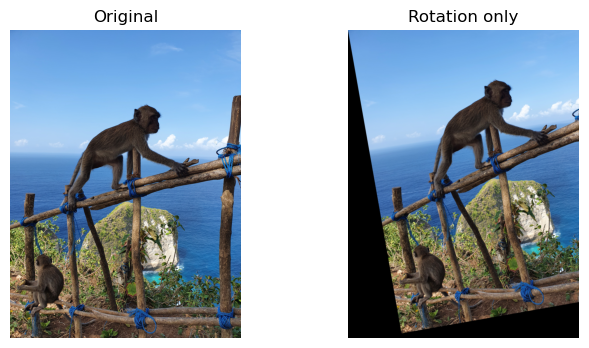

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


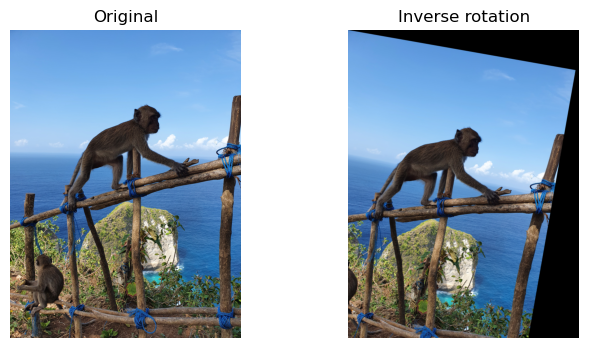

In [13]:
tform_rot = EuclideanTransform(rotation=rotation_angle_rad)
img_rot = warp(im_org, tform_rot)
img_rot_inv = warp(im_org, tform_rot.inverse)

show_comparison(im_org, img_rot, "Rotation only")
show_comparison(im_org, img_rot_inv, "Inverse rotation")

Exercise 9

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


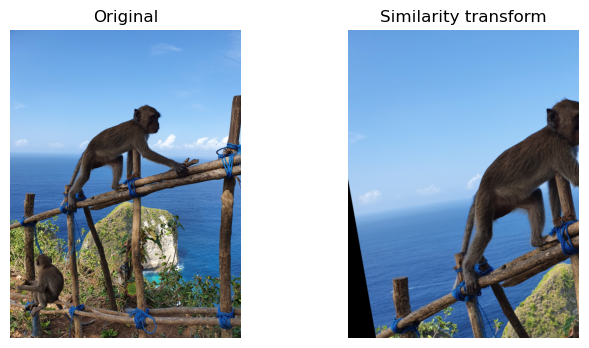

In [15]:
from skimage.transform import SimilarityTransform

tform_sim = SimilarityTransform(scale=0.6,
                                rotation=rotation_angle_rad,
                                translation=(40, 30))
img_sim = warp(im_org, tform_sim)

show_comparison(im_org, img_sim, "Similarity transform")

Exercise 10

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


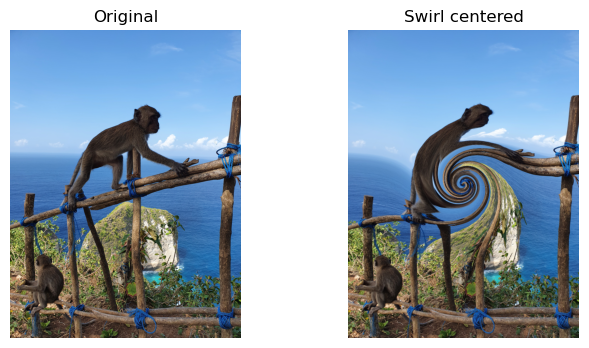

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


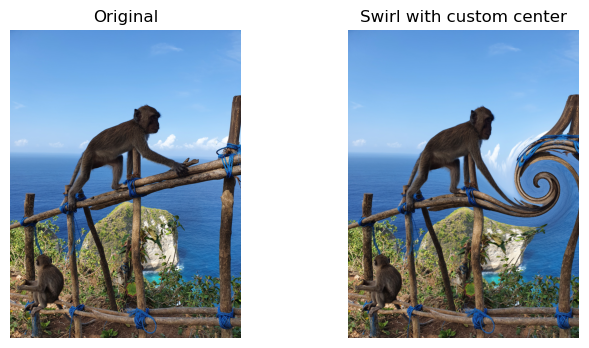

In [16]:
from skimage.transform import swirl

swirl_img1 = swirl(im_org, strength=10, radius=300)
swirl_img2 = swirl(im_org, strength=10, radius=300, center=(500, 400))

show_comparison(im_org, swirl_img1, "Swirl centered")
show_comparison(im_org, swirl_img2, "Swirl with custom center")

Exercise 11

C:\Users\frede\AppData\Local\Temp\ipykernel_25732\27170891.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


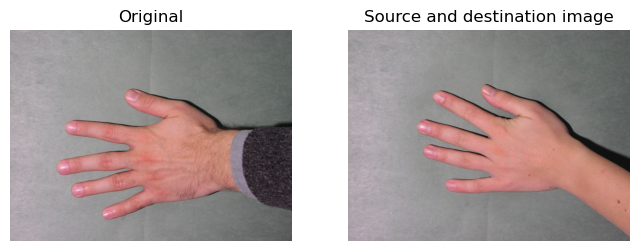

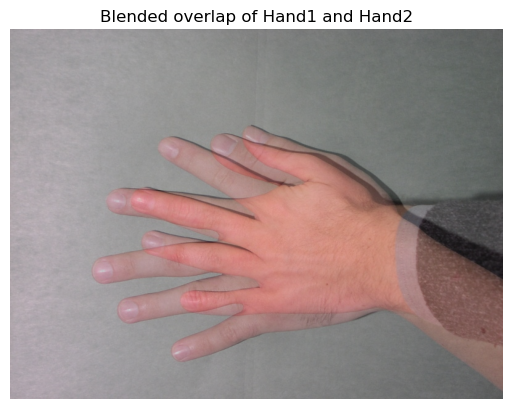

In [18]:
from skimage.util import img_as_float

src_img = io.imread("data/Hand1.jpg")
dst_img = io.imread("data/Hand2.jpg")

# Blend them together to visualize overlap
blend = 0.5 * img_as_float(src_img) + 0.5 * img_as_float(dst_img)
show_comparison(src_img, dst_img, "Source and destination image")

plt.imshow(blend)
plt.title("Blended overlap of Hand1 and Hand2")
plt.axis("off")
plt.show()

Exercise 12

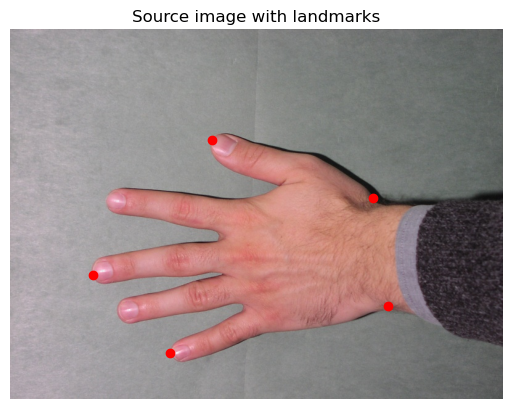

In [19]:
src = np.array([
    [588, 274],
    [328, 179],
    [134, 398],
    [260, 525],
    [613, 448]
])

plt.imshow(src_img)
plt.plot(src[:, 0], src[:, 1], '.r', markersize=12)
plt.title("Source image with landmarks")
plt.axis("off")
plt.show()

Exercise 13

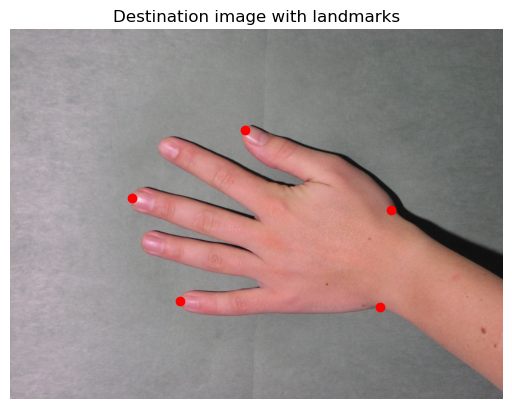

In [22]:
dst = np.array ([
    [618, 293],
    [381, 163],
    [198, 273],
    [276, 441],
    [600, 450]
])

plt.imshow(dst_img)
plt.plot(dst[:, 0], dst[:, 1], '.r', markersize=12)
plt.title("Destination image with landmarks")
plt.axis("off")
plt.show()

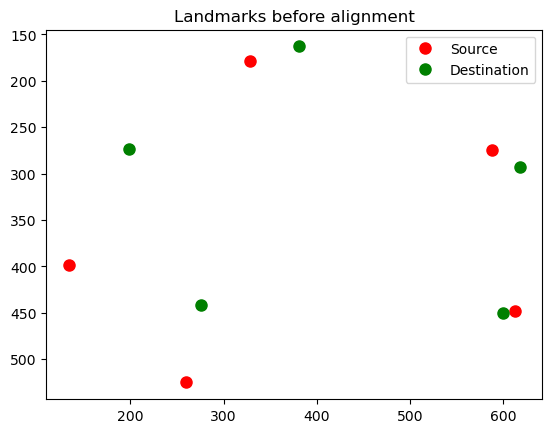

In [23]:
fig, ax = plt.subplots()
ax.plot(src[:, 0], src[:, 1], 'or', markersize=8, label="Source")       # red circles
ax.plot(dst[:, 0], dst[:, 1], 'og', markersize=8, label="Destination")  # green circles
ax.invert_yaxis()  # match image coordinate system
ax.legend()
ax.set_title("Landmarks before alignment")
plt.show()


Exercise 14

In [25]:
e_x = src[:, 0] - dst[:, 0]
error_x = np.dot(e_x, e_x)
e_y = src[:, 1] - dst[:, 1]
error_y = np.dot(e_y, e_y)
F_before = error_x + error_y
print(f"Initial landmark alignment error F: {F_before}")

Initial landmark alignment error F: 31532


In [27]:
from skimage.transform import EuclideanTransform, matrix_transform

tform = EuclideanTransform()
tform.estimate(src, dst)
print("Estimated transform matrix:\n", tform.params)

src_transform = matrix_transform(src, tform.params)

Estimated transform matrix:
 [[   0.9684147    -0.24934507  133.10878538]
 [   0.24934507    0.9684147  -125.17579642]
 [   0.            0.            1.        ]]


Exercise 15

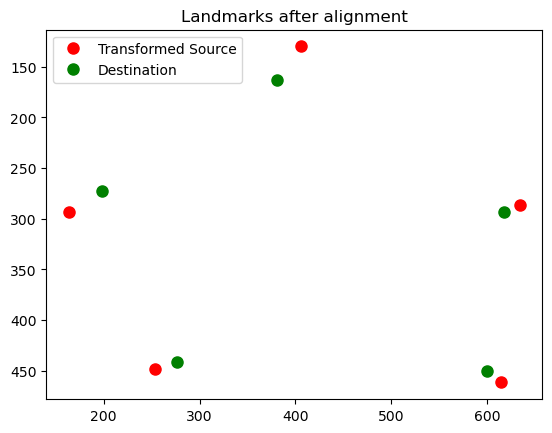

In [28]:
fig, ax = plt.subplots()
ax.plot(src_transform[:, 0], src_transform[:, 1], 'or', markersize=8, label="Transformed Source")
ax.plot(dst[:, 0], dst[:, 1], 'og', markersize=8, label="Destination")
ax.invert_yaxis()
ax.legend()
ax.set_title("Landmarks after alignment")
plt.show()

In [29]:
e_x = src_transform[:, 0] - dst[:, 0]
error_x = np.dot(e_x, e_x)
e_y = src_transform[:, 1] - dst[:, 1]
error_y = np.dot(e_y, e_y)
F_aligned = error_x + error_y
print(f"Landmark alignment error after transform F: {F_aligned}")

Landmark alignment error after transform F: 4525.625510396609


The distance is way smaller and the objective function is also 1/7 of the original

Exercise 16

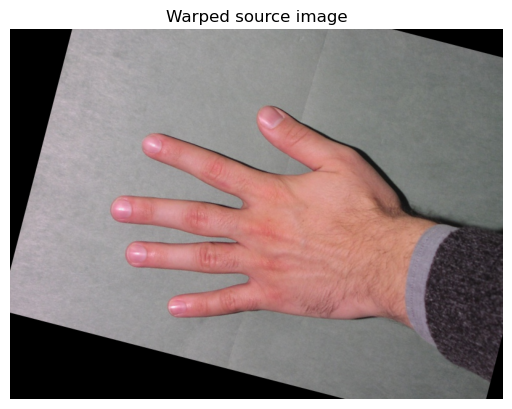

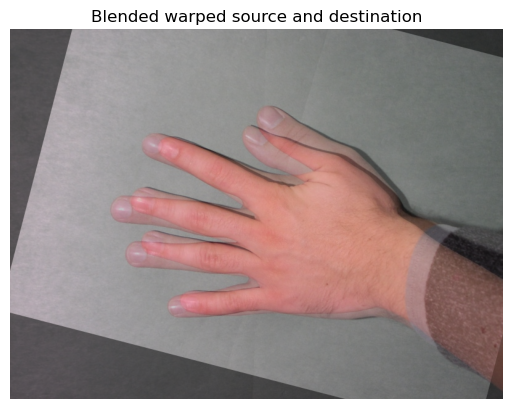

In [30]:
warped = warp(src_img, tform.inverse)

# Show the warped image
plt.imshow(warped)
plt.title("Warped source image")
plt.axis("off")
plt.show()

# Blend warped source with destination
blend = 0.5 * img_as_float(warped) + 0.5 * img_as_float(dst_img)
plt.imshow(blend)
plt.title("Blended warped source and destination")
plt.axis("off")
plt.show()

Looks a lot better but still not perfect. The fingers are too long and the angle between the thumb and the rest of the hand is different